# FX Benchmark Analysis

This notebook analyzes FX benchmark data collected from the Deluge.

## Prerequisites

1. Build with benchmarking: `./dbt configure -DENABLE_FX_BENCHMARK=ON -DENABLE_SYSEX_LOAD=YES && ./dbt build release`
2. Collect data: `dbt fx-benchmark --collect --label baseline`
3. Data is saved to `contrib/analysis/data/fx_bench_<label>.csv`

## Collecting Before/After Data

```bash
dbt fx-benchmark --collect --label before   # baseline measurement
# ... make firmware changes ...
dbt fx-benchmark --collect --label after    # measure improvement
```

The comparison section at the bottom auto-discovers all datasets in `data/`.

## CSV Format

New format (v2): `fx,cycles,cps,n,ts,tags`
- **cycles**: raw total cycle count for the measurement
- **cps**: cycles per sample (cycles / numSamples) — the primary normalized metric
- **n**: render window size in samples (varies 4–128 per buffer)
- **ts**: PMU timestamp
- **tags**: comma-separated context tags (output name, voice count, etc.)

Legacy format (v1): `fx,cycles,ts,tags` — auto-detected and cps computed from `n<XX>` tags

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import re

# Configuration
DATA_DIR = "data"  # Durable benchmark data directory
CSV_PATH = "../../fx_benchmark.csv"  # Legacy single-file path (fallback)
CPU_FREQ_HZ = 400_000_000  # 400 MHz Cortex-A9
SAMPLE_RATE = 44100
BUFFER_SIZE = 128  # SSI_TX_BUFFER_NUM_SAMPLES

# Calculate cycles per audio buffer at 100% CPU
CYCLES_PER_BUFFER = CPU_FREQ_HZ / SAMPLE_RATE * BUFFER_SIZE
print(f"CPU: {CPU_FREQ_HZ / 1e6:.0f} MHz")
print(f"Sample rate: {SAMPLE_RATE} Hz")
print(f"Buffer size: {BUFFER_SIZE} samples")
print(f"Cycles per buffer (100% CPU): {CYCLES_PER_BUFFER:,.0f}")

# Discover available datasets
datasets = {}
if os.path.isdir(DATA_DIR):
    for f in sorted(glob.glob(os.path.join(DATA_DIR, "fx_bench_*.csv"))):
        label = os.path.basename(f).replace("fx_bench_", "").replace(".csv", "")
        datasets[label] = f
if os.path.exists(CSV_PATH) and not datasets:
    datasets["default"] = CSV_PATH

print(f"\nAvailable datasets: {list(datasets.keys())}")
for label, path in datasets.items():
    print(f"  {label}: {path}")

CPU: 400 MHz
Sample rate: 44100 Hz
Buffer size: 128 samples
Cycles per buffer (100% CPU): 1,160,998

Available datasets: ['after', 'baseline', 'before']
  after: data/fx_bench_after.csv
  baseline: data/fx_bench_baseline.csv
  before: data/fx_bench_before.csv


In [121]:
def load_benchmark(path):
    """Load a benchmark CSV, auto-detecting v1 vs v2 format."""
    df = pd.read_csv(path)
    if "cps" in df.columns and "n" in df.columns:
        df["tags_list"] = (
            df["tags"].fillna("").apply(lambda x: x.split(",") if x else [])
        )
    else:
        df["tags_list"] = (
            df["tags"].fillna("").apply(lambda x: x.split(",") if x else [])
        )

        def extract_n(tags_list):
            for t in tags_list:
                m = re.match(r"^n(\d+)$", t.strip())
                if m:
                    return int(m.group(1))
            return 0

        df["n"] = df["tags_list"].apply(extract_n)
        df["cps"] = df.apply(
            lambda r: r["cycles"] // r["n"] if r["n"] > 0 else r["cycles"], axis=1
        )
    return df


# Load primary dataset (first available, or override ACTIVE_DATASET below)
ACTIVE_DATASET = list(datasets.keys())[0]  # Change to pick a specific dataset
active_path = datasets[ACTIVE_DATASET]
df = load_benchmark(active_path)

print(f"Active dataset: '{ACTIVE_DATASET}' ({active_path})")
print(f"Loaded {len(df)} samples")
print(f"Effects: {df['fx'].unique().tolist()}")
print(f"Window sizes (n): {sorted(df['n'].unique())}")
df.head()

Active dataset: 'after' (data/fx_bench_after.csv)
Loaded 677 samples
Effects: ['sound', 'sine_shaper', 'disperser', 'automod', 'song', 'reverb_mutable', 'buffer']
Window sizes (n): [128]


,fx,cycles,cps,n,ts,tags,tags_list
0,sound,2151,16,128,-581777028,"setup,v1","[setup, v1]"
1,sine_shaper,1764,13,128,-581756705,"setup,z0_cheby","[setup, z0_cheby]"
2,sine_shaper,22919,179,128,-581754869,"loop,z0_cheby","[loop, z0_cheby]"
3,sine_shaper,24862,194,128,-581756740,"total,z0_cheby","[total, z0_cheby]"
4,sound,53576,418,128,-581774762,"voices,v1","[voices, v1]"


## Summary Statistics

In [122]:
# Filter to "total" entries for effects that have substage breakdown
SUBSTAGE_KEYWORDS = {
    "setup",
    "loop",
    "crossover",
    "envelope",
    "recombine",
    "slice",
    "params",
    "paramread",
    "static",
    "envprep",
    "env",
    "pan",
    "delay",
    "record",
    "read",
    "advance",
}


def is_total_or_non_substage(row):
    """Return True if this row represents total DSP (not a substage)"""
    tags = row["tags"] if pd.notna(row["tags"]) else ""
    tags_lower = tags.lower()
    if "total" in tags_lower:
        return True
    for kw in SUBSTAGE_KEYWORDS:
        if kw in tags_lower:
            return False
    return True


df_totals = df[df.apply(is_total_or_non_substage, axis=1)].copy()
print(f"Filtered to {len(df_totals)} total/non-substage samples (from {len(df)} total)")

# CPS-based summary (primary metric)
summary_cps = df_totals.groupby("fx")["cps"].agg(
    ["count", "mean", "std", "median", "min", "max"]
)
summary_cps = summary_cps.round(0).astype(int)
summary_cps = summary_cps.sort_values("mean", ascending=False)

print("\nFX Benchmark Summary — Cycles per Sample (sorted by mean):")
print("=" * 80)
print(summary_cps.to_string())

# Also show raw cycles for total-buffer context
summary_raw = df_totals.groupby("fx")["cycles"].agg(["mean", "median", "max"])
summary_raw["cpu_percent"] = (summary_raw["mean"] / CYCLES_PER_BUFFER) * 100
summary_raw = summary_raw.round(1).sort_values("mean", ascending=False)
print("\nRaw cycles (for total-buffer load context):")
print(summary_raw.to_string())

Filtered to 461 total/non-substage samples (from 677 total)

FX Benchmark Summary — Cycles per Sample (sorted by mean):
                count  mean   std  median   min   max
fx                                                   
buffer             29  7451   252    7562  6715  7752
disperser          29  2112     5    2113  2103  2119
song              116  1575  1329    1062     2  3324
sound             200   892  1004     404    18  2859
reverb_mutable     29   698    56     727   583   736
automod            29   219     1     219   215   220
sine_shaper        29   194     1     194   193   198

Raw cycles (for total-buffer load context):
                    mean    median     max  cpu_percent
fx                                                     
buffer          953769.3  967952.0  992276         82.2
disperser       270354.2  270513.0  271285         23.3
song            201683.7  135970.0  425577         17.4
sound           114265.9   51706.0  365953          9.8
reverb_mutabl

## CPS Histograms by Effect

Cycles per sample — directly comparable across different window sizes.

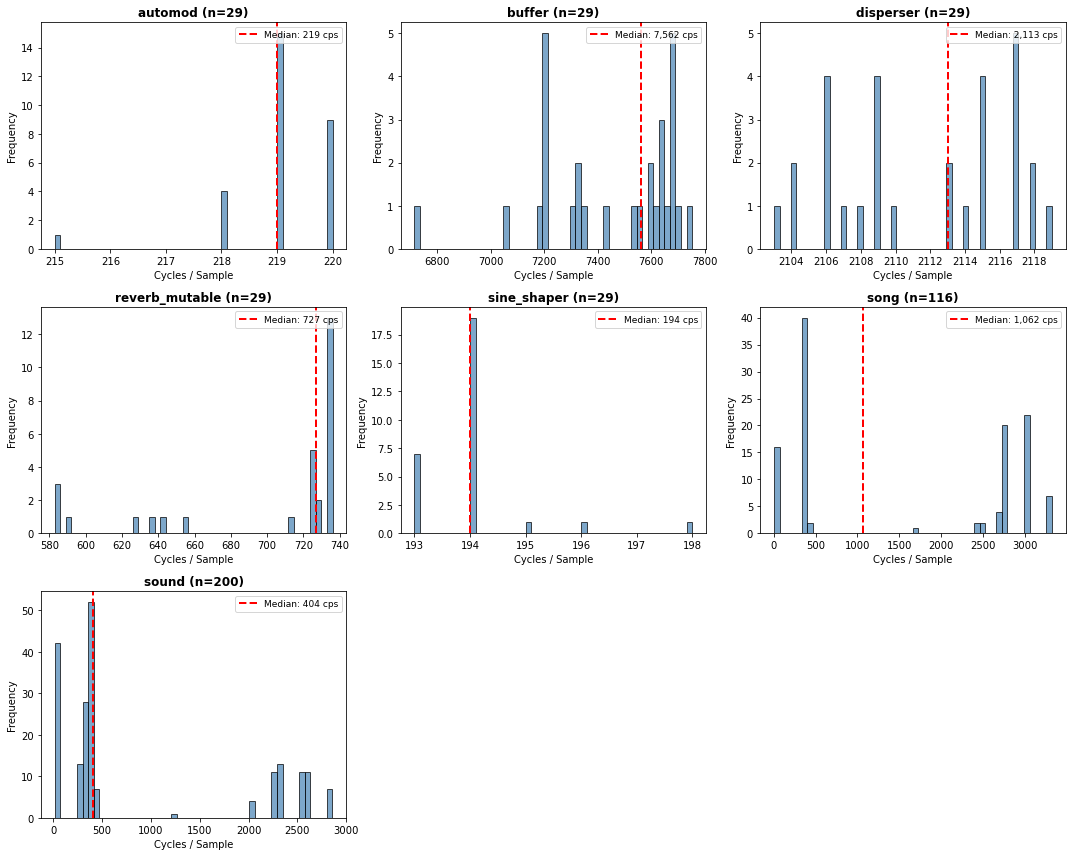

Saved: fx_benchmark_histograms.png


In [123]:
# CPS histograms per effect (using totals only)
effects = df_totals["fx"].unique()
n_effects = len(effects)

n_cols = min(3, n_effects)
n_rows = (n_effects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_effects == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, fx_name in enumerate(sorted(effects)):
    ax = axes[idx]
    fx_data = df_totals[df_totals["fx"] == fx_name]["cps"]

    ax.hist(fx_data, bins=50, edgecolor="black", alpha=0.7, color="steelblue")

    median_val = fx_data.median()
    ax.axvline(
        median_val,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Median: {median_val:,.0f} cps",
    )

    ax.set_title(f"{fx_name} (n={len(fx_data)})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Cycles / Sample")
    ax.set_ylabel("Frequency")
    ax.legend(loc="upper right", fontsize=9)

for idx in range(n_effects, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(
    "fx_benchmark_histograms.png", dpi=150, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved: fx_benchmark_histograms.png")

## CPU Load Comparison (Bar Chart)

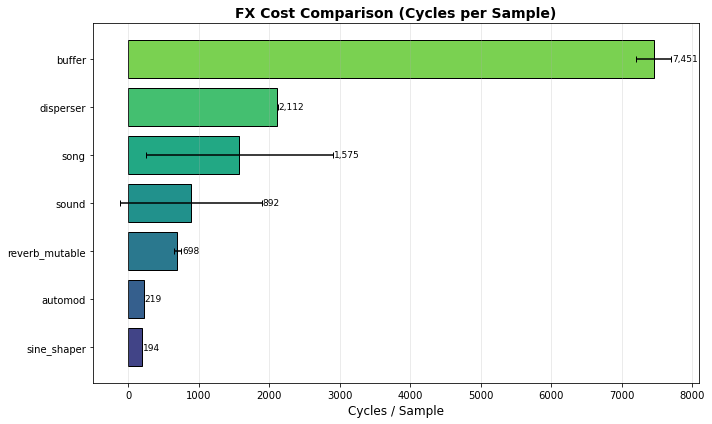

Saved: fx_benchmark_comparison.png


In [124]:
# CPS bar chart comparison (using totals only)
fig, ax = plt.subplots(figsize=(10, 6))

fx_means = df_totals.groupby("fx")["cps"].mean().sort_values(ascending=True)
fx_stds = df_totals.groupby("fx")["cps"].std().reindex(fx_means.index)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(fx_means)))

bars = ax.barh(
    range(len(fx_means)),
    fx_means,
    xerr=fx_stds,
    color=colors,
    edgecolor="black",
    capsize=3,
)

ax.set_yticks(range(len(fx_means)))
ax.set_yticklabels(fx_means.index)
ax.set_xlabel("Cycles / Sample", fontsize=12)
ax.set_title("FX Cost Comparison (Cycles per Sample)", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

for i, (cps_val, bar) in enumerate(zip(fx_means, bars)):
    ax.text(
        cps_val + fx_stds.iloc[i] + 10, i, f"{cps_val:,.0f}", va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "fx_benchmark_comparison.png", dpi=150, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved: fx_benchmark_comparison.png")

## Time Series (Optional)

If you collected data over time, this shows how cycle counts vary.

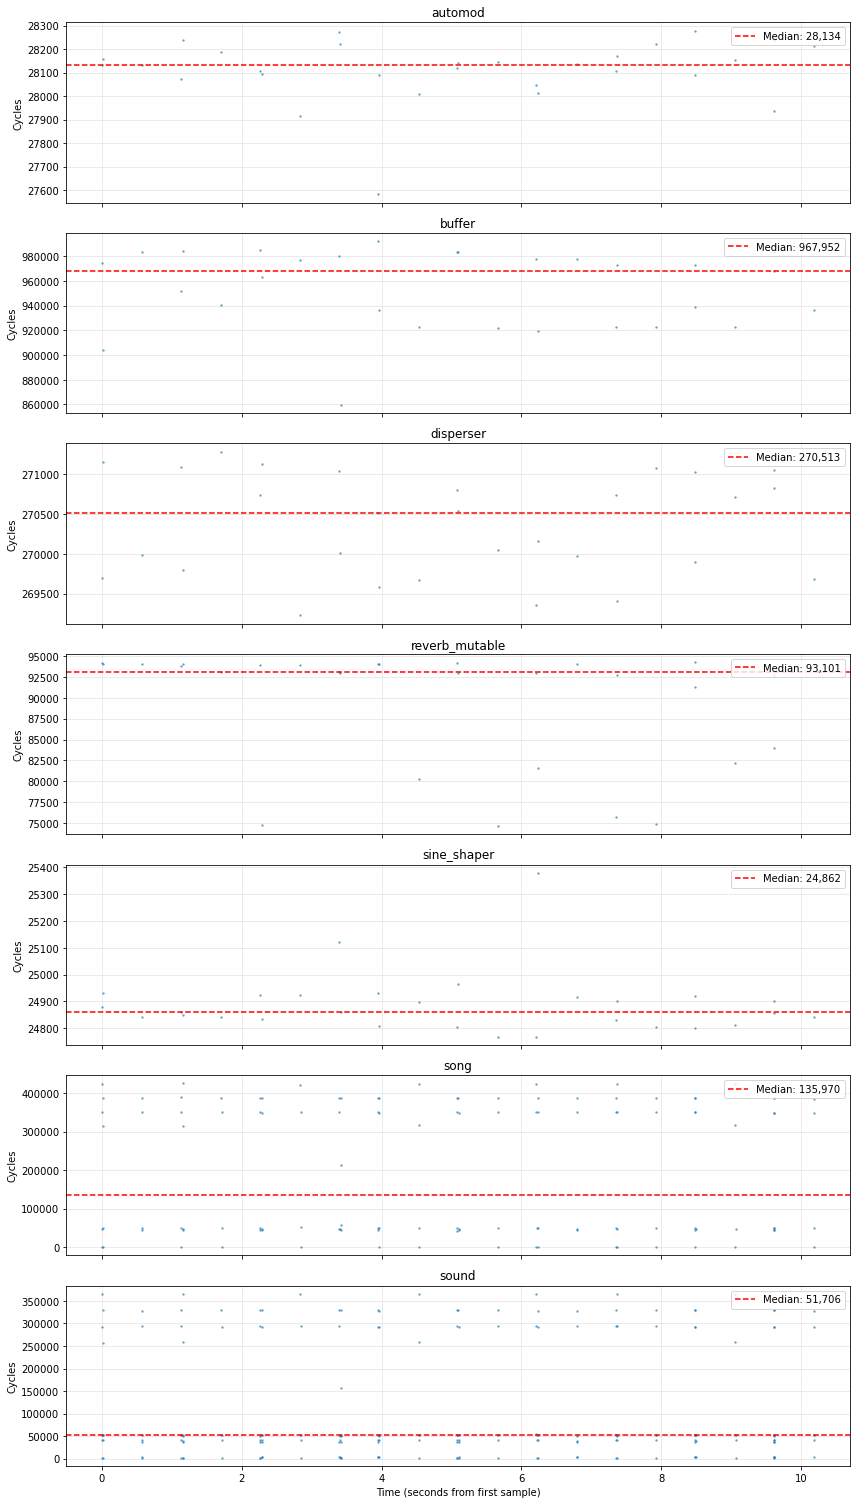

Saved: fx_benchmark_timeseries.png


In [125]:
# Time series plot - cycles over timestamp (using totals only)
if "ts" in df_totals.columns and df_totals["ts"].notna().any():
    fig, axes = plt.subplots(
        len(effects), 1, figsize=(12, 3 * len(effects)), sharex=True
    )
    if len(effects) == 1:
        axes = [axes]

    for ax, fx_name in zip(axes, sorted(effects)):
        fx_data = df_totals[df_totals["fx"] == fx_name].sort_values("ts")

        # Normalize timestamp to seconds from start
        if len(fx_data) > 0:
            t0 = fx_data["ts"].iloc[0]
            time_sec = (fx_data["ts"] - t0) / CPU_FREQ_HZ

            ax.plot(time_sec, fx_data["cycles"], ".", alpha=0.5, markersize=3)
            ax.axhline(
                fx_data["cycles"].median(),
                color="red",
                linestyle="--",
                label=f"Median: {fx_data['cycles'].median():,.0f}",
            )
            ax.set_ylabel("Cycles")
            ax.set_title(fx_name)
            ax.legend(loc="upper right")
            ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Time (seconds from first sample)")
    plt.tight_layout()
    plt.savefig(
        "fx_benchmark_timeseries.png", dpi=150, bbox_inches="tight", facecolor="white"
    )
    plt.show()
    print("Saved: fx_benchmark_timeseries.png")
else:
    print("No timestamp data available for time series plot")

## Per-Output CPS Breakdown

Compare outputs on a normalized basis — CPS removes window size as a confound.

Per-Output CPS Summary:
                count  mean  median  std   max
output_name                                   
Dub Fold           29  3095    3029  123  3324
Atmosphere Dx7     29  2662    2733  214  2750
303A               29   387     385   16   456
Chirp              29   158       3  175   366


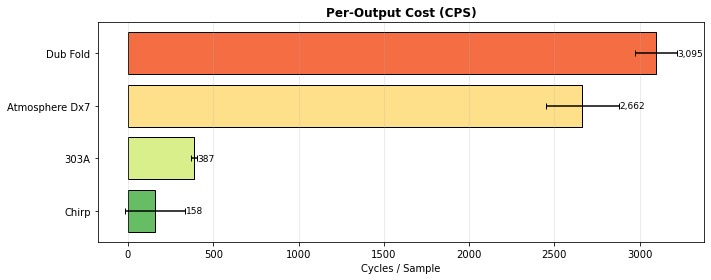

In [126]:
# Per-output CPS breakdown (from song/output bench entries)
df_song = df_totals[df_totals["fx"] == "song"].copy()

if len(df_song) > 0:
    # Extract output name from tags (first tag after "output")
    def get_output_name(tags_list):
        for i, t in enumerate(tags_list):
            if t.strip() == "output" and i + 1 < len(tags_list):
                return tags_list[i + 1].strip()
        return "unknown"

    df_song["output_name"] = df_song["tags_list"].apply(get_output_name)
    df_song = df_song[df_song["output_name"] != "unknown"]

    if len(df_song) > 0:
        # CPS summary per output
        output_summary = (
            df_song.groupby("output_name")["cps"]
            .agg(["count", "mean", "median", "std", "max"])
            .round(0)
            .astype(int)
            .sort_values("mean", ascending=False)
        )

        print("Per-Output CPS Summary:")
        print("=" * 70)
        print(output_summary.to_string())

        # Bar chart
        fig, ax = plt.subplots(figsize=(10, max(4, len(output_summary) * 0.6)))
        means = output_summary["mean"].sort_values(ascending=True)
        stds = output_summary.loc[means.index, "std"]

        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(means)))
        bars = ax.barh(
            range(len(means)),
            means,
            xerr=stds,
            color=colors,
            edgecolor="black",
            capsize=3,
        )

        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_xlabel("Cycles / Sample")
        ax.set_title("Per-Output Cost (CPS)", fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

        for i, (v, bar) in enumerate(zip(means, bars)):
            ax.text(v + stds.iloc[i] + 5, i, f"{v:,}", va="center", fontsize=9)

        plt.tight_layout()
        plt.show()
    else:
        print("No output name tags found in song entries.")
else:
    print("No song/output bench entries found.")

## Heavy-Tail Analysis

Are CPU spikes driven by a few extreme outliers (heavy tail), or is the distribution well-behaved?

- **Kurtosis > 0**: heavier tails than normal (leptokurtic) — spikes are disproportionately large
- **Skewness > 0**: right-skewed — tail extends toward high cost
- **P95/Median ratio**: how much worse the worst 5% is vs typical. >2x suggests spiky behavior.

In [127]:
from scipy import stats as sp_stats

# Heavy-tail metrics per effect (using cps for apples-to-apples comparison)
print("Heavy-Tail Distribution Analysis (CPS)")
print("=" * 90)
print(
    f"{'Effect':<20} {'N':>5} {'Median':>8} {'P95':>8} {'P99':>8} {'P95/Med':>8} {'Skew':>7} {'Kurt':>7}"
)
print("-" * 90)

for fx_name in sorted(df_totals["fx"].unique()):
    data = df_totals[df_totals["fx"] == fx_name]["cps"]
    if len(data) < 5:
        continue
    med = data.median()
    p95 = data.quantile(0.95)
    p99 = data.quantile(0.99)
    ratio = p95 / med if med > 0 else float("inf")
    skew = data.skew()
    kurt = data.kurtosis()  # excess kurtosis (0 = normal)
    print(
        f"{fx_name:<20} {len(data):>5} {med:>8,.0f} {p95:>8,.0f} {p99:>8,.0f} {ratio:>8.2f} {skew:>7.2f} {kurt:>7.2f}"
    )

print()
print("Kurtosis: >0 = heavier than normal, <0 = lighter. Skew: >0 = right tail.")
print(
    "P95/Median ratio: how much worse worst 5% is vs typical. >2x suggests spiky behavior."
)

Heavy-Tail Distribution Analysis (CPS)
Effect                   N   Median      P95      P99  P95/Med    Skew    Kurt
------------------------------------------------------------------------------------------
automod                 29      219      220      220     1.00   -2.26    8.12
buffer                  29    7,562    7,691    7,736     1.02   -0.99    0.75
disperser               29    2,113    2,118    2,119     1.00   -0.15   -1.46
reverb_mutable          29      727      735      736     1.01   -1.27   -0.06
sine_shaper             29      194      196      197     1.01    2.53    9.04
song                   116    1,062    3,299    3,317     3.11    0.03   -1.93
sound                  200      404    2,578    2,851     6.39    0.93   -0.96

Kurtosis: >0 = heavier than normal, <0 = lighter. Skew: >0 = right tail.
P95/Median ratio: how much worse worst 5% is vs typical. >2x suggests spiky behavior.


## Buffer CPS Distribution & Setup Overhead Analysis

The key model: `CPS = per_sample_cost + per_buffer_setup / n`

- **per_sample_cost**: cycles per sample that scale linearly with window size (DSP loops)
- **per_buffer_setup**: fixed cycles per buffer regardless of window size (LFO updates, cache checks, coefficient recalc)

By fitting CPS vs 1/n, we directly extract the aggregate per-buffer setup overhead without instrumenting individual effects. If `per_buffer_setup` is large relative to `per_sample_cost * n`, staggering window sizes will help smooth spikes.

ValueError: Cannot calculate a linear regression if all x values are identical

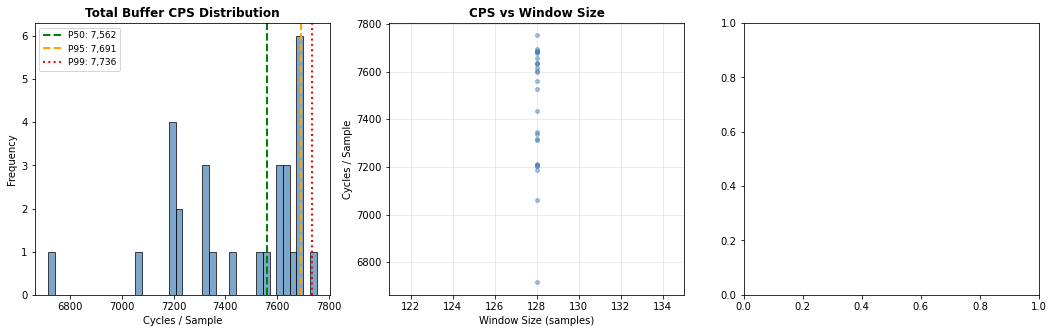

In [128]:
# Total buffer CPS analysis — extract aggregate per-buffer setup overhead
df_buffer = df_totals[df_totals["fx"] == "buffer"]

if len(df_buffer) > 5:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cps_data = df_buffer["cps"]
    n_data = df_buffer["n"]

    # --- Left: CPS histogram with percentile markers ---
    ax = axes[0]
    ax.hist(cps_data, bins=40, edgecolor="black", alpha=0.7, color="steelblue")
    for pct, color, ls in [(50, "green", "--"), (95, "orange", "--"), (99, "red", ":")]:
        val = cps_data.quantile(pct / 100)
        ax.axvline(
            val, color=color, linestyle=ls, linewidth=2, label=f"P{pct}: {val:,.0f}"
        )
    ax.set_xlabel("Cycles / Sample")
    ax.set_ylabel("Frequency")
    ax.set_title("Total Buffer CPS Distribution", fontweight="bold")
    ax.legend(fontsize=9)

    # --- Center: CPS vs window size scatter ---
    ax = axes[1]
    ax.scatter(n_data, cps_data, alpha=0.5, s=15, color="steelblue")
    ax.set_xlabel("Window Size (samples)")
    ax.set_ylabel("Cycles / Sample")
    ax.set_title("CPS vs Window Size", fontweight="bold")
    ax.grid(alpha=0.3)

    # Fit CPS = a + b/n via linear regression on (1/n)
    inv_n = 1.0 / n_data
    slope_b, intercept_a, r, p_val, se = sp_stats.linregress(inv_n, cps_data)

    # Plot fit curve
    n_range = np.linspace(max(4, n_data.min()), n_data.max(), 200)
    cps_fit = intercept_a + slope_b / n_range
    ax.plot(
        n_range,
        cps_fit,
        "r-",
        linewidth=2,
        label=f"Fit: CPS = {intercept_a:,.0f} + {slope_b:,.0f}/n\nr²={r**2:.3f}",
    )
    ax.legend(fontsize=9)

    # --- Right: Setup overhead analysis ---
    ax = axes[2]
    # Show what fraction of total cost is setup at each window size
    n_points = np.array([8, 16, 32, 64, 128])
    total_cost = intercept_a * n_points + slope_b
    setup_frac = slope_b / total_cost * 100

    ax.bar(range(len(n_points)), setup_frac, color="coral", edgecolor="black")
    ax.set_xticks(range(len(n_points)))
    ax.set_xticklabels([f"n={n}" for n in n_points])
    ax.set_ylabel("Setup Overhead (%)")
    ax.set_title("Per-Buffer Setup as % of Total Cost", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for i, (frac, n) in enumerate(zip(setup_frac, n_points)):
        ax.text(
            i, frac + 1, f"{frac:.1f}%", ha="center", fontsize=10, fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(
        "fx_benchmark_buffer_analysis.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

    # Print summary
    print(f"\nModel: CPS = {intercept_a:,.0f} + {slope_b:,.0f} / n   (r² = {r**2:.3f})")
    print(f"  per_sample_cost  = {intercept_a:,.0f} cycles/sample (DSP loops)")
    print(f"  per_buffer_setup = {slope_b:,.0f} cycles (LFOs, caches, coefficients)")
    print()
    print("Setup overhead by window size:")
    for n in [8, 16, 32, 64, 128]:
        total = intercept_a * n + slope_b
        pct = slope_b / total * 100
        print(
            f"  n={n:3d}: setup = {pct:5.1f}% of total ({slope_b:,.0f} / {total:,.0f} cycles)"
        )
    print()
    if slope_b > intercept_a * 16:
        print(
            ">> SIGNIFICANT per-buffer overhead at small windows. Staggering may help."
        )
    else:
        print(
            ">> Per-buffer overhead is small relative to per-sample cost. Staggering unlikely to help."
        )

elif len(df_buffer) > 0:
    print(f"Only {len(df_buffer)} buffer samples — need more data for curve fitting.")
    print("Collect longer benchmarks to populate this analysis.")
else:
    print(
        "No 'buffer' (total) entries found. Collect new data with total-buffer bench enabled."
    )

In [ ]:
# Per-output setup overhead decomposition
# Fit CPS = a + b/n for each output independently
df_song = df_totals[df_totals["fx"] == "song"].copy()

if len(df_song) > 0:

    def get_output_name(tags_list):
        for i, t in enumerate(tags_list):
            if t.strip() == "output" and i + 1 < len(tags_list):
                return tags_list[i + 1].strip()
        return None

    df_song["output_name"] = df_song["tags_list"].apply(get_output_name)
    df_song = df_song[df_song["output_name"].notna() & (df_song["n"] > 0)]

    if len(df_song) > 0:
        print("Per-Output Setup Overhead Decomposition: CPS = per_sample + setup/n")
        print("=" * 85)
        print(
            f"{'Output':<25} {'N':>4} {'per_sample':>12} {'setup (cyc)':>12} {'r²':>6} {'setup@n=16':>10}"
        )
        print("-" * 85)

        for name in sorted(df_song["output_name"].unique()):
            odata = df_song[df_song["output_name"] == name]
            if len(odata) < 3 or odata["n"].nunique() < 2:
                continue
            inv_n = 1.0 / odata["n"]
            b, a, r, p_val, se = sp_stats.linregress(inv_n, odata["cps"])
            setup_pct_16 = b / (a * 16 + b) * 100 if (a * 16 + b) > 0 else 0
            print(
                f"{name:<25} {len(odata):>4} {a:>12,.0f} {b:>12,.0f} {r**2:>6.3f} {setup_pct_16:>9.1f}%"
            )

        print()
        print("setup@n=16: what % of cost is per-buffer setup when window=16 samples")
        print("Outputs with high setup% are candidates for staggering benefit.")
else:
    print("No per-output data available.")

Per-Output Setup Overhead Decomposition: CPS = per_sample + setup/n
Output                       N   per_sample  setup (cyc)     r² setup@n=16
-------------------------------------------------------------------------------------
303A                        68          275       11,441  0.899      72.2%
Atmosphere Dx7              68        1,989       13,519  0.081      29.8%
Chirp                       68          472      -10,871  0.069       0.0%
Dub Fold                    68        1,983       71,419  0.561      69.2%

setup@n=16: what % of cost is per-buffer setup when window=16 samples
Outputs with high setup% are candidates for staggering benefit.


## Analysis by Tags

Detailed breakdown by tag combinations (output names, voice counts, stage counts, etc.)

In [ ]:
# Check if we have tagged data
df_with_tags = df[df["tags"].notna() & (df["tags"] != "")]

if len(df_with_tags) > 0:
    print("Effects with tags:")
    for fx in df_with_tags["fx"].unique():
        fx_tags = df_with_tags[df_with_tags["fx"] == fx]
        print(f"\n{fx}:")
        for tag in fx_tags["tags"].unique():
            tag_data = fx_tags[fx_tags["tags"] == tag]["cycles"]
            print(
                f"  {tag}: {len(tag_data)} samples, median {tag_data.median():,.0f} cycles"
            )
else:
    print("No tagged data found")

Effects with tags:

sound:
  setup,v1: 231 samples, median 1,973 cycles
  voices,v1: 231 samples, median 22,260 cycles
  fx,v1: 231 samples, median 17,535 cycles

sine_shaper:
  setup,z0_cheby: 68 samples, median 1,732 cycles
  loop,z0_cheby: 68 samples, median 8,102 cycles
  total,z0_cheby: 68 samples, median 10,001 cycles

disperser:
  s32: 68 samples, median 95,356 cycles

automod:
  setup: 68 samples, median 2,032 cycles
  loop: 68 samples, median 9,031 cycles
  total: 68 samples, median 11,450 cycles

song:
  output,Dub Fold,o4: 68 samples, median 160,482 cycles
  output,Chirp,o4: 68 samples, median 390 cycles
  output,Atmosphere Dx7,o4: 68 samples, median 96,404 cycles
  output,303A,o4: 68 samples, median 23,576 cycles

buffer:
  total: 68 samples, median 343,066 cycles


In [ ]:
# Export summary to markdown for documentation
print("\n## Markdown Summary — Cycles per Sample (copy to docs)\n")
print("| Effect | Count | Mean CPS | Median CPS | Std | Max CPS |")
print("|--------|-------|----------|------------|-----|---------|")
for fx in summary_cps.index:
    row = summary_cps.loc[fx]
    print(
        f"| {fx} | {int(row['count'])} | {row['mean']:,} | {row['median']:,} | {row['std']:,} | {row['max']:,} |"
    )


## Markdown Summary — Cycles per Sample (copy to docs)

| Effect | Count | Mean CPS | Median CPS | Std | Max CPS |
|--------|-------|----------|------------|-----|---------|
| buffer | 68 | 8,184 | 7,852 | 860 | 10,195 |
| disperser | 68 | 2,187 | 2,184 | 32 | 2,265 |
| song | 272 | 1,696 | 1,234 | 1,455 | 5,357 |
| sound | 462 | 948 | 476 | 1,048 | 4,524 |
| reverb_mutable | 68 | 696 | 742 | 100 | 779 |
| automod | 68 | 263 | 262 | 15 | 308 |
| sine_shaper | 68 | 231 | 230 | 14 | 271 |


## Before / After Comparison

Load two labeled datasets and compare CPS distributions, P95/median ratios, setup overhead, and window size distributions. Requires at least two datasets in `data/` (e.g., `fx_bench_before.csv` and `fx_bench_after.csv`).

Usage:
```
dbt fx-benchmark --collect --label before   # collect baseline
# ... make changes ...
dbt fx-benchmark --collect --label after    # collect with changes
```

'after': 461 total samples, n range [128-128]
'baseline': 1074 total samples, n range [24-64]
'before': 698 total samples, n range [17-72]

KEY METRICS COMPARISON: before vs after
Metric                                  before           after      delta   change
-----------------------------------------------------------------------------------------------
Buffer CPS (median)                    8,064.0         7,562.0      -502   -6.2%
Buffer CPS (P95)                       8,769.4         7,691.2    -1,078  -12.3%
Buffer CPS (max)                      11,165.0         7,752.0    -3,413  -30.6%
Buffer CPS (std)                         626.7           251.9      -375  -59.8%
Buffer P95/Median ratio                    1.1             1.0        -0   -6.5%
Min window size (n)                         17             128 +      111 + 652.9%
Median window size (n)                      48             128 +       80 + 166.7%
Song P95/Median ratio                      2.7             3.1 +      

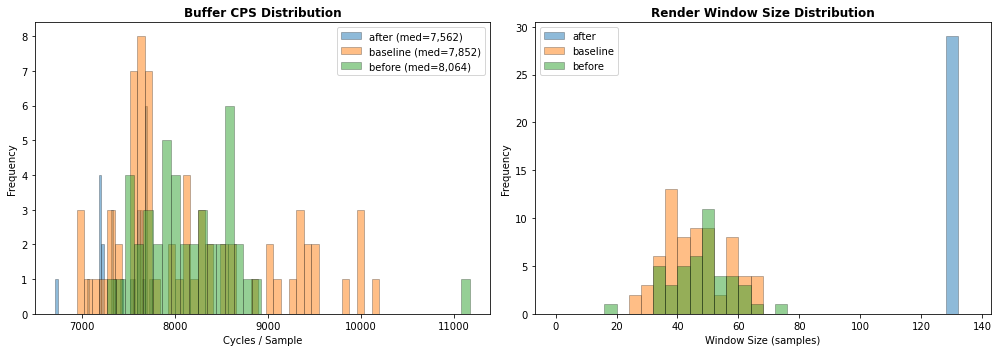

Saved: fx_benchmark_comparison_ab.png


In [ ]:
# Before/After comparison — load all datasets and compare key metrics

# Primary comparison pair (override if your labels differ)
COMPARE_BEFORE = "before"
COMPARE_AFTER = "after"

if len(datasets) < 2:
    print(f"Only {len(datasets)} dataset(s) found. Need at least 2 for comparison.")
    print("Collect data with labels:")
    print("  dbt fx-benchmark --collect --label before")
    print("  dbt fx-benchmark --collect --label after")
elif COMPARE_BEFORE not in datasets or COMPARE_AFTER not in datasets:
    print(f"Need '{COMPARE_BEFORE}' and '{COMPARE_AFTER}' datasets for comparison.")
    print(f"Available: {list(datasets.keys())}")
else:
    # Load all datasets for overlay plots, but compare before/after explicitly
    all_dfs = {}
    for label, path in datasets.items():
        d = load_benchmark(path)
        d_totals = d[d.apply(is_total_or_non_substage, axis=1)].copy()
        all_dfs[label] = d_totals
        print(
            f"'{label}': {len(d_totals)} total samples, n range [{d_totals['n'].min()}-{d_totals['n'].max()}]"
        )

    labels = list(all_dfs.keys())
    da = all_dfs[COMPARE_BEFORE]
    db = all_dfs[COMPARE_AFTER]

    # --- 1. Key metrics comparison table (before vs after with deltas) ---
    print(f"\n{'=' * 95}")
    print(f"KEY METRICS COMPARISON: {COMPARE_BEFORE} vs {COMPARE_AFTER}")
    print("=" * 95)
    header = f"{'Metric':<30} {COMPARE_BEFORE:>15} {COMPARE_AFTER:>15} {'delta':>10} {'change':>8}"
    print(header)
    print("-" * 95)

    def metric_row(name, val_before, val_after):
        row = f"{name:<30}"
        for v in [val_before, val_after]:
            row += f" {v:>15,.1f}" if isinstance(v, float) else f" {v:>15,}"
        delta = val_after - val_before
        pct = (delta / val_before * 100) if val_before != 0 else 0
        sign = "+" if delta > 0 else ""
        row += f" {sign}{delta:>9,.0f} {sign}{pct:>6.1f}%"
        print(row)

    # Buffer CPS metrics
    buf_a = da[da["fx"] == "buffer"]
    buf_b = db[db["fx"] == "buffer"]

    if len(buf_a) > 0 and len(buf_b) > 0:
        for metric_name, col, agg in [
            ("Buffer CPS (median)", "cps", "median"),
            ("Buffer CPS (P95)", "cps", lambda x: x.quantile(0.95)),
            ("Buffer CPS (max)", "cps", "max"),
            ("Buffer CPS (std)", "cps", "std"),
        ]:
            va = float(buf_a[col].agg(agg))
            vb = float(buf_b[col].agg(agg))
            metric_row(metric_name, va, vb)

        # P95/Median ratio for buffer
        med_a = buf_a["cps"].median()
        med_b = buf_b["cps"].median()
        r_a = float(buf_a["cps"].quantile(0.95) / med_a) if med_a > 0 else 0.0
        r_b = float(buf_b["cps"].quantile(0.95) / med_b) if med_b > 0 else 0.0
        metric_row("Buffer P95/Median ratio", r_a, r_b)

        # Window size stats
        metric_row("Min window size (n)", int(buf_a["n"].min()), int(buf_b["n"].min()))
        metric_row(
            "Median window size (n)", int(buf_a["n"].median()), int(buf_b["n"].median())
        )

    # Song P95/Median
    song_a = da[da["fx"] == "song"]["cps"]
    song_b = db[db["fx"] == "song"]["cps"]
    if len(song_a) > 0 and len(song_b) > 0:
        med_sa = song_a.median()
        med_sb = song_b.median()
        r_sa = float(song_a.quantile(0.95) / med_sa) if med_sa > 0 else 0.0
        r_sb = float(song_b.quantile(0.95) / med_sb) if med_sb > 0 else 0.0
        metric_row("Song P95/Median ratio", r_sa, r_sb)

    # --- 2. CPS distribution overlay (all datasets for context) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Buffer CPS overlay
    ax = axes[0]
    colors = plt.cm.tab10.colors
    for i, label in enumerate(labels):
        buf = all_dfs[label][all_dfs[label]["fx"] == "buffer"]["cps"]
        if len(buf) > 0:
            ax.hist(
                buf,
                bins=40,
                alpha=0.5,
                color=colors[i],
                label=f"{label} (med={buf.median():,.0f})",
                edgecolor="black",
                linewidth=0.5,
            )
    ax.set_xlabel("Cycles / Sample")
    ax.set_ylabel("Frequency")
    ax.set_title("Buffer CPS Distribution", fontweight="bold")
    ax.legend()

    # Right: Window size (n) distribution overlay
    ax = axes[1]
    for i, label in enumerate(labels):
        buf = all_dfs[label][all_dfs[label]["fx"] == "buffer"]["n"]
        if len(buf) > 0:
            ax.hist(
                buf,
                bins=range(0, 140, 4),
                alpha=0.5,
                color=colors[i],
                label=f"{label}",
                edgecolor="black",
                linewidth=0.5,
            )
    ax.set_xlabel("Window Size (samples)")
    ax.set_ylabel("Frequency")
    ax.set_title("Render Window Size Distribution", fontweight="bold")
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        "fx_benchmark_comparison_ab.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    print("Saved: fx_benchmark_comparison_ab.png")

## Experiment Report Generator

Run the cell below to generate a PR-ready markdown report. Copy the output into your PR description or save as an attachment. Images are saved alongside for upload.

In [ ]:
# Generate experiment report as markdown file
# Edit EXPERIMENT_DESCRIPTION and CHANGE_DESCRIPTION before running

EXPERIMENT_DESCRIPTION = (
    "Enforce minimum render window size to reduce per-buffer setup overhead"
)
CHANGE_DESCRIPTION = "Added minimum buffer size threshold in audio engine renderAudio()"

REPORT_PATH = "experiment_report.md"

# Which two datasets to compare (before = control, after = treatment)
LABEL_BEFORE = "before"
LABEL_AFTER = "after"


def generate_report():
    lines = []
    lines.append(f"# Experiment Report: {EXPERIMENT_DESCRIPTION}\n")

    # --- Context ---
    lines.append("## Background\n")
    lines.append(
        "The Deluge audio engine renders variable-size buffers (4-128 samples) depending on"
    )
    lines.append(
        "main-loop scheduling pressure. Per-buffer setup work (LFO updates, coefficient"
    )
    lines.append(
        "recalculation, cache checks) is amortized over the window size. Small windows pay"
    )
    lines.append(
        "disproportionate overhead: at n=8, setup is ~69% of total cost vs ~12% at n=128.\n"
    )
    lines.append(f"**Change:** {CHANGE_DESCRIPTION}\n")

    # --- Methodology ---
    lines.append("## Methodology\n")
    lines.append(
        "- Firmware built with `ENABLE_FX_BENCHMARK=ON` (PMU cycle counter instrumentation)"
    )
    lines.append(
        "- 1-in-3450 buffer sampling (~10s intervals) to minimize observer effect"
    )
    lines.append("- Benchmark data collected via MIDI sysex debug channel")
    lines.append(
        f"- CPU: {CPU_FREQ_HZ / 1e6:.0f} MHz ARM Cortex-A9, sample rate: {SAMPLE_RATE} Hz"
    )
    lines.append("- Metric: **CPS** (cycles per sample) = total_cycles / window_size\n")

    # Check required datasets exist
    if LABEL_BEFORE not in datasets or LABEL_AFTER not in datasets:
        missing = []
        if LABEL_BEFORE not in datasets:
            missing.append(LABEL_BEFORE)
        if LABEL_AFTER not in datasets:
            missing.append(LABEL_AFTER)
        lines.append("## Results\n")
        lines.append(f"**Missing dataset(s): {', '.join(missing)}.**")
        lines.append(f"Available: {list(datasets.keys())}")
        lines.append(
            f"Collect with: `dbt fx-benchmark --collect --label {missing[0]}`\n"
        )
        report = "\n".join(lines)
        with open(REPORT_PATH, "w") as f:
            f.write(report)
        print(f"Partial report saved to {REPORT_PATH}")
        print(report)
        return

    # Load before/after datasets
    all_data = {}
    for label in [LABEL_BEFORE, LABEL_AFTER]:
        d = load_benchmark(datasets[label])
        all_data[label] = d[d.apply(is_total_or_non_substage, axis=1)].copy()

    da, db = all_data[LABEL_BEFORE], all_data[LABEL_AFTER]

    lines.append("## Datasets\n")
    lines.append(f"| | {LABEL_BEFORE} | {LABEL_AFTER} |")
    lines.append("|---|---|---|")
    lines.append(f"| Samples | {len(da)} | {len(db)} |")
    buf_a = da[da["fx"] == "buffer"]
    buf_b = db[db["fx"] == "buffer"]
    if len(buf_a) > 0 and len(buf_b) > 0:
        lines.append(
            f"| Window range | {buf_a['n'].min()}-{buf_a['n'].max()} | {buf_b['n'].min()}-{buf_b['n'].max()} |"
        )
    lines.append("")

    # --- Key Results ---
    lines.append("## Key Results\n")
    lines.append(f"| Metric | {LABEL_BEFORE} | {LABEL_AFTER} | Change |")
    lines.append("|--------|----------|---------|--------|")

    def fmt_change(before, after):
        if before == 0:
            return "N/A"
        delta = after - before
        pct = delta / before * 100
        sign = "+" if delta > 0 else ""
        arrow = "worse" if pct > 5 else ("better" if pct < -5 else "~same")
        return f"{sign}{pct:.1f}% ({arrow})"

    if len(buf_a) > 0 and len(buf_b) > 0:
        for name, agg_fn in [
            ("Buffer CPS median", lambda s: float(s.median())),
            ("Buffer CPS P95", lambda s: float(s.quantile(0.95))),
            ("Buffer CPS max", lambda s: float(s.max())),
            ("Buffer CPS std", lambda s: float(s.std())),
        ]:
            va = agg_fn(buf_a["cps"])
            vb = agg_fn(buf_b["cps"])
            lines.append(f"| {name} | {va:,.0f} | {vb:,.0f} | {fmt_change(va, vb)} |")

        # P95/Median
        med_a, med_b = buf_a["cps"].median(), buf_b["cps"].median()
        r_a = buf_a["cps"].quantile(0.95) / med_a if med_a > 0 else 0
        r_b = buf_b["cps"].quantile(0.95) / med_b if med_b > 0 else 0
        lines.append(
            f"| P95/Median ratio | {r_a:.2f}x | {r_b:.2f}x | {fmt_change(r_a, r_b)} |"
        )

        # Min window
        lines.append(f"| Min window size | {buf_a['n'].min()} | {buf_b['n'].min()} | |")
        lines.append(
            f"| Median window size | {buf_a['n'].median():.0f} | {buf_b['n'].median():.0f} | |"
        )

    lines.append("")

    # --- Per-effect CPS comparison ---
    lines.append("## Per-Effect CPS Comparison\n")
    lines.append(f"| Effect | {LABEL_BEFORE} median | {LABEL_AFTER} median | Change |")
    lines.append("|--------|----------|---------|--------|")

    common_effects = sorted(set(da["fx"].unique()) & set(db["fx"].unique()))
    for fx in common_effects:
        va = float(da[da["fx"] == fx]["cps"].median())
        vb = float(db[db["fx"] == fx]["cps"].median())
        lines.append(f"| {fx} | {va:,.0f} | {vb:,.0f} | {fmt_change(va, vb)} |")
    lines.append("")

    # --- Setup overhead model ---
    lines.append("## Setup Overhead Model\n")
    lines.append("Fitted model: `CPS = per_sample_cost + per_buffer_setup / n`\n")

    model_fits = {}
    for label, buf_df in [(LABEL_BEFORE, buf_a), (LABEL_AFTER, buf_b)]:
        if len(buf_df) > 5 and buf_df["n"].nunique() > 1:
            inv_n = 1.0 / buf_df["n"]
            b, a, r, _, _ = sp_stats.linregress(inv_n, buf_df["cps"])
            model_fits[label] = (a, b, r)

    if len(model_fits) == 2:
        lines.append(f"| Parameter | {LABEL_BEFORE} | {LABEL_AFTER} |")
        lines.append("|-----------|----------|---------|")
        a_a, b_a, r_a = model_fits[LABEL_BEFORE]
        a_b, b_b, r_b = model_fits[LABEL_AFTER]
        lines.append(f"| per_sample_cost | {a_a:,.0f} | {a_b:,.0f} |")
        lines.append(f"| per_buffer_setup | {b_a:,.0f} | {b_b:,.0f} |")
        lines.append(f"| r\u00b2 | {r_a**2:.3f} | {r_b**2:.3f} |")
    elif LABEL_BEFORE in model_fits:
        a_a, b_a, r_a = model_fits[LABEL_BEFORE]
        lines.append(f"Before: CPS = {a_a:,.0f} + {b_a:,.0f}/n (r\u00b2={r_a**2:.3f})")
        lines.append("After: all windows n=128, setup overhead eliminated by design.")
    else:
        lines.append("Insufficient data for model fitting.")
    lines.append("")

    # --- Interpretation ---
    lines.append("## Interpretation\n")
    if len(buf_a) > 0 and len(buf_b) > 0:
        med_before = float(buf_a["cps"].median())
        med_after = float(buf_b["cps"].median())
        p95_before = float(buf_a["cps"].quantile(0.95))
        p95_after = float(buf_b["cps"].quantile(0.95))
        std_before = float(buf_a["cps"].std())
        std_after = float(buf_b["cps"].std())

        if p95_after < p95_before * 0.9:
            lines.append(
                "Results show **significant improvement** in worst-case CPU load:"
            )
        elif p95_after < p95_before:
            lines.append("Results show **modest improvement** in worst-case CPU load:")
        else:
            lines.append(
                "Results show **no significant change** in worst-case CPU load:"
            )

        lines.append(
            f"- P95 CPS: {p95_before:,.0f} \u2192 {p95_after:,.0f} ({fmt_change(p95_before, p95_after)})"
        )
        lines.append(
            f"- Median CPS: {med_before:,.0f} \u2192 {med_after:,.0f} ({fmt_change(med_before, med_after)})"
        )
        lines.append(
            f"- CPS std dev: {std_before:,.0f} \u2192 {std_after:,.0f} ({fmt_change(std_before, std_after)})"
        )

        min_n_before = buf_a["n"].min()
        min_n_after = buf_b["n"].min()
        if min_n_after > min_n_before:
            lines.append(
                f"- Minimum window size: {min_n_before} \u2192 {min_n_after} (setup overhead amortized)"
            )
        lines.append("")

    # --- Images ---
    lines.append("## Figures\n")
    lines.append("![Before/After CPS Distribution](fx_benchmark_comparison_ab.png)\n")
    lines.append("![Setup Overhead Model](fx_benchmark_buffer_analysis.png)\n")

    # Write report
    report = "\n".join(lines)
    with open(REPORT_PATH, "w") as f:
        f.write(report)
    print(f"Report saved to {REPORT_PATH}")
    print("=" * 60)
    print(report)


generate_report()